# TimeXer Phase 3 — Result Inspection

Loads `pred.npy`, `true.npy`, `subjects.npy` from `results/` and computes:
- Per-participant RMSE at the full 30-min horizon
- Per-horizon RMSE (how error grows from t+5 → t+30)
- Dataset-level summary
- Ground truth vs prediction plots

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────────────────
RESULTS_ROOT = Path('../results')
SETTING_BASE = (
    'long_term_forecast_combined_24_6_TimeXer_combined_'
    'ftMS_sl24_ll6_pl6_dm128_nh4_el2_dl1_df256_expand2_dc4_fc3_'
    'ebtimeF_dtTrue_TimeXer-BGlucose-combined'
)
DATASETS   = ['ohio', 'bris', 'hupa']
HORIZONS   = [5, 10, 15, 20, 25, 30]   # minutes ahead for each pred step
PRED_LEN   = 6                          # number of prediction steps

In [2]:
# ── Load all results ──────────────────────────────────────────────────────────
data = {}
for tag in DATASETS:
    path = RESULTS_ROOT / f'{SETTING_BASE}_{tag}'
    pred     = np.load(path / 'pred.npy').squeeze(-1)      # (N, 6)  mg/dL
    true     = np.load(path / 'true.npy').squeeze(-1)      # (N, 6)  mg/dL
    subjects = np.load(path / 'subjects.npy')              # (N,)    strings
    metrics  = np.load(path / 'metrics.npy')               # [MAE, MSE, RMSE, MAPE, MSPE]
    data[tag] = dict(pred=pred, true=true, subjects=subjects, metrics=metrics)
    print(f'{tag:5s}: {len(pred):>6,} windows  |  '
          f'{len(np.unique(subjects)):>2} subjects  |  '
          f'overall RMSE = {metrics[2]:.2f} mg/dL')

ohio : 12,093 windows  |   6 subjects  |  overall RMSE = 13.89 mg/dL
bris : 85,998 windows  |  15 subjects  |  overall RMSE = 17.58 mg/dL
hupa : 31,787 windows  |  22 subjects  |  overall RMSE = 10.90 mg/dL


## 1. Per-Participant RMSE — Full 30-min Horizon
RMSE is computed across **all 6 prediction steps** (t+5 … t+30) and all windows for each subject.

In [5]:
def per_subject_rmse(pred, true, subjects):
    """Returns a DataFrame with one row per subject."""
    rows = []
    for subj in np.unique(subjects):
        mask = subjects == subj
        p = pred[mask]   # (n_windows, 6)
        t = true[mask]
        rmse_full   = np.sqrt(np.mean((p - t) ** 2))           # all steps combined
        rmse_30min  = np.sqrt(np.mean((p[:, -1] - t[:, -1]) ** 2))  # t+30 only
        mae_full    = np.mean(np.abs(p - t))
        rows.append(dict(
            subject    = subj,
            n_windows  = mask.sum(),
            rmse_full  = rmse_full,
            rmse_30min = rmse_30min,
            mae_full   = mae_full,
        ))
    return pd.DataFrame(rows).sort_values('rmse_full')

results_df = {}
for tag in DATASETS:
    d = data[tag]
    df = per_subject_rmse(d['pred'], d['true'], d['subjects'])
    results_df[tag] = df
    print(f'\n=== {tag.upper()} ===')
    print(df.to_string(index=False, float_format='{:.2f}'.format))
    print(f'  Dataset mean RMSE (full horizon): {df.rmse_full.mean():.2f} ± {df.rmse_full.std():.2f} mg/dL')
    print(f'  Dataset mean RMSE (t+30 only):    {df.rmse_30min.mean():.2f} ± {df.rmse_30min.std():.2f} mg/dL')


=== OHIO ===
 subject  n_windows  rmse_full  rmse_30min  mae_full
ohio_570       1923      11.08       16.38      7.19
ohio_588       2261      12.98       19.15      8.69
ohio_559       1781      13.45       20.34      8.84
ohio_591       1992      13.63       20.05      9.24
ohio_563       2133      14.05       19.46      9.09
ohio_575       2003      17.37       24.64     10.10
  Dataset mean RMSE (full horizon): 13.76 ± 2.05 mg/dL
  Dataset mean RMSE (t+30 only):    20.00 ± 2.67 mg/dL

=== BRIS ===
 subject  n_windows  rmse_full  rmse_30min  mae_full
bris_P19       8579      14.79       21.74     10.00
bris_P12       6420      14.87       21.82      9.83
bris_P16       6631      15.79       23.31     10.58
bris_P17       5952      16.01       23.46     10.68
bris_P10       5778      16.05       23.19     11.04
bris_P03       3812      16.25       24.04     11.16
bris_P04       7010      17.14       24.90     11.45
bris_P23       2702      17.22       25.06     11.26
bris_P11      

## 2. Per-Horizon RMSE — How Error Grows Over Time
RMSE at each prediction step (t+5, t+10, ..., t+30), averaged across all windows.

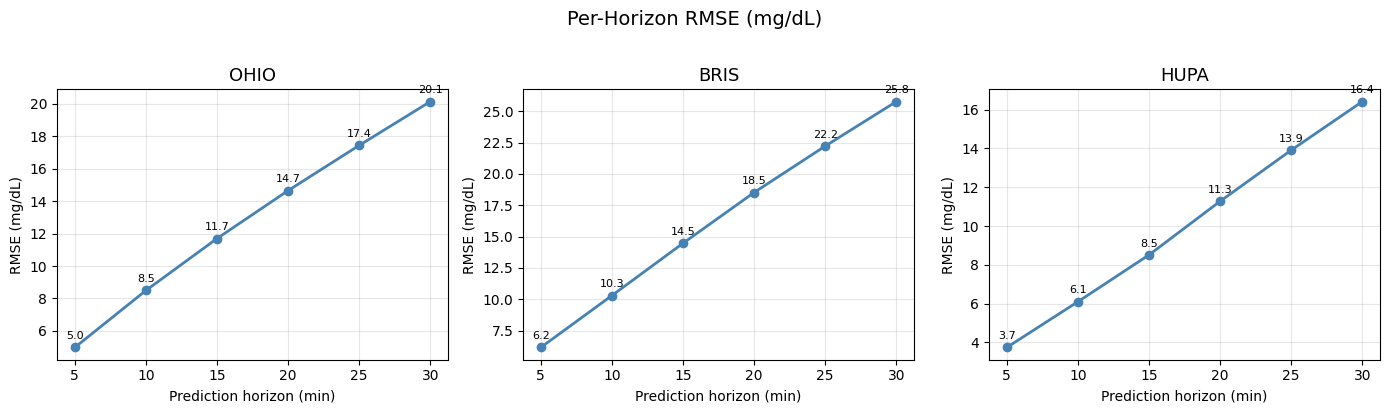

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for ax, tag in zip(axes, DATASETS):
    d = data[tag]
    # Per-horizon RMSE: sqrt(mean over windows of squared error at each step)
    horizon_rmse = np.sqrt(np.mean((d['pred'] - d['true']) ** 2, axis=0))   # (6,)
    ax.plot(HORIZONS, horizon_rmse, marker='o', linewidth=2, color='steelblue')
    ax.set_title(tag.upper(), fontsize=13)
    ax.set_xlabel('Prediction horizon (min)')
    ax.set_ylabel('RMSE (mg/dL)')
    ax.set_xticks(HORIZONS)
    ax.grid(alpha=0.3)
    for x, y in zip(HORIZONS, horizon_rmse):
        ax.annotate(f'{y:.1f}', (x, y), textcoords='offset points', xytext=(0, 6),
                    ha='center', fontsize=8)

plt.suptitle('Per-Horizon RMSE (mg/dL)', fontsize=14, y=1.02)
plt.tight_layout()
# plt.savefig('../test_results/per_horizon_rmse.pdf', bbox_inches='tight')
plt.show()

## 3. Dataset Summary Table
Comparison across datasets at each prediction horizon.

In [6]:
rows = []
for tag in DATASETS:
    d = data[tag]
    horizon_rmse = np.sqrt(np.mean((d['pred'] - d['true']) ** 2, axis=0))
    horizon_mae  = np.mean(np.abs(d['pred'] - d['true']), axis=0)
    row = {'dataset': tag.upper(), 'n_subjects': len(np.unique(d['subjects'])),
           'n_windows': len(d['pred'])}
    for i, h in enumerate(HORIZONS):
        row[f'RMSE_t+{h}'] = round(horizon_rmse[i], 2)
    row['RMSE_mean'] = round(horizon_rmse.mean(), 2)
    rows.append(row)

summary = pd.DataFrame(rows).set_index('dataset')
print(summary.to_string())

         n_subjects  n_windows  RMSE_t+5  RMSE_t+10  RMSE_t+15  RMSE_t+20  RMSE_t+25  RMSE_t+30  RMSE_mean
dataset                                                                                                   
OHIO              6      12093      4.98       8.49      11.69      14.65  17.440001  20.139999      12.90
BRIS             15      85998      6.15      10.29      14.47      18.52  22.219999  25.770000      16.24
HUPA             22      31787      3.74       6.10       8.51      11.27  13.900000  16.410000       9.99


## 4. Ground Truth vs Prediction — Full 30-min Horizon
Plots a random sample of windows showing the 2-hr lookback context and the 30-min prediction vs ground truth.

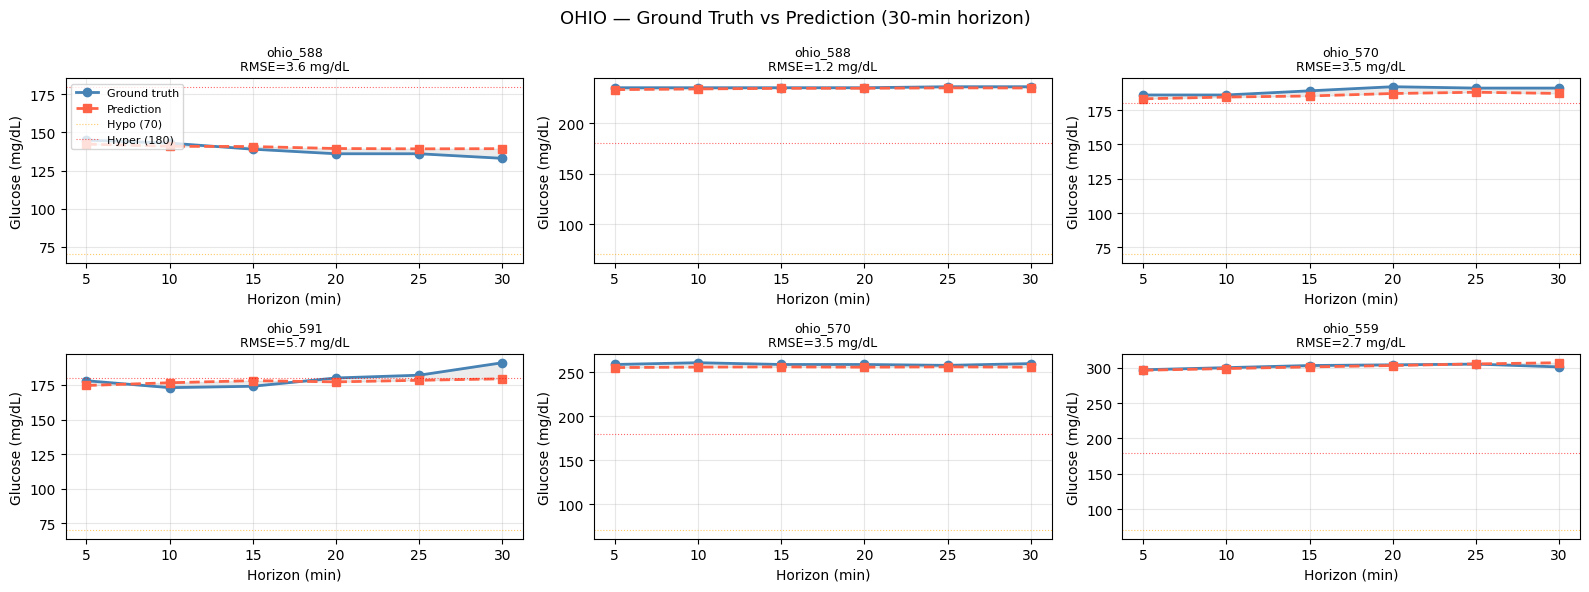

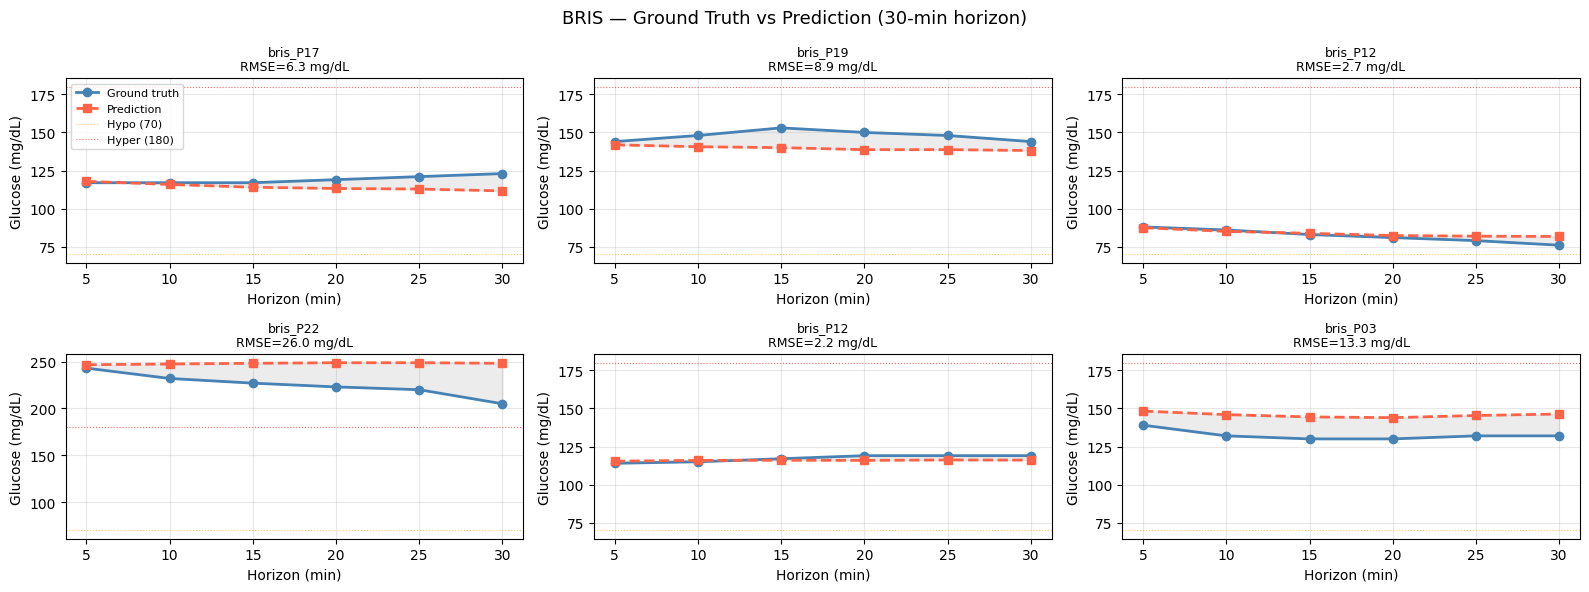

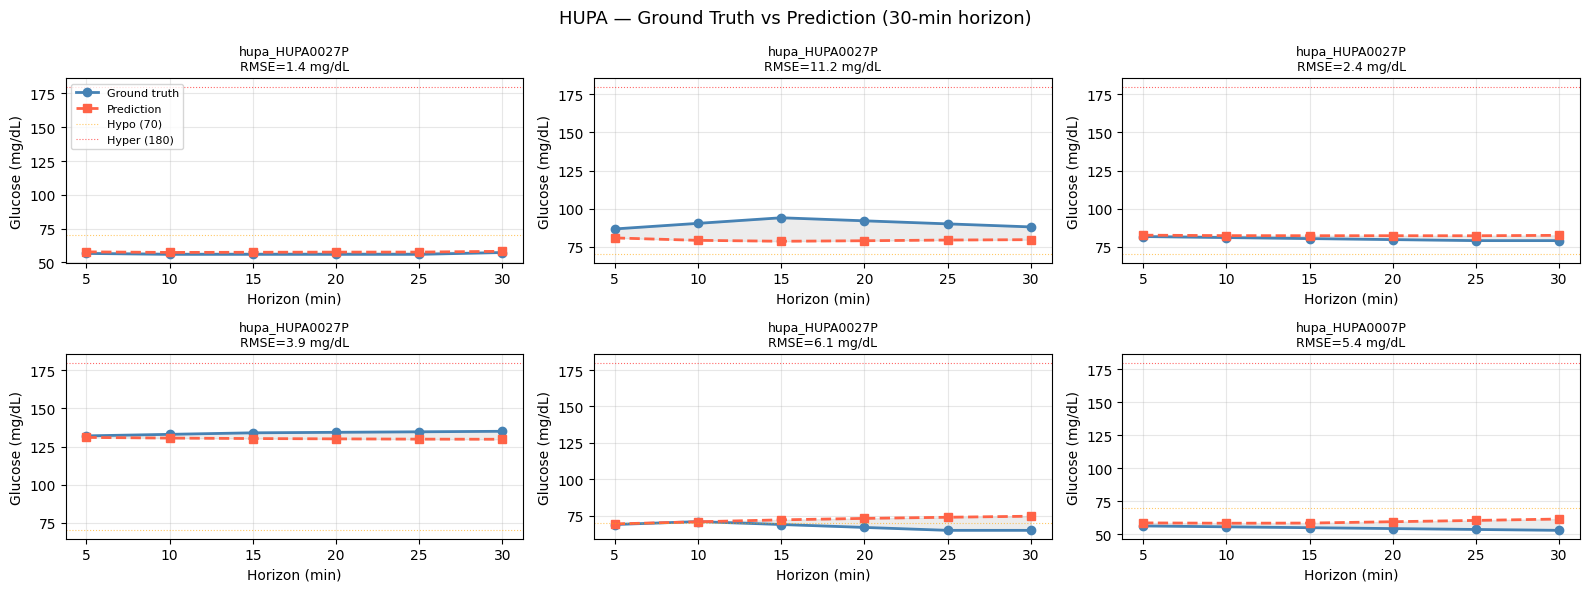

In [8]:
def plot_gt_vs_pred(tag, n_examples=6, seed=42):
    """Show n_examples windows: context (grey) + ground truth (blue) + prediction (red)."""
    rng  = np.random.default_rng(seed)
    d    = data[tag]
    idx  = rng.choice(len(d['pred']), n_examples, replace=False)

    fig, axes = plt.subplots(2, n_examples // 2, figsize=(16, 6))
    axes = axes.flatten()

    for ax, i in zip(axes, idx):
        t_axis_future = np.array(HORIZONS)           # 5..30 min ahead

        gt   = d['true'][i]    # (6,)  ground truth
        pred = d['pred'][i]    # (6,)  prediction

        ax.plot(t_axis_future, gt,   'o-', color='steelblue', label='Ground truth', linewidth=2)
        ax.plot(t_axis_future, pred, 's--', color='tomato',   label='Prediction',   linewidth=2)
        ax.fill_between(t_axis_future, gt, pred, alpha=0.15, color='grey')

        rmse_i = np.sqrt(np.mean((pred - gt) ** 2))
        subj   = d['subjects'][i]
        ax.set_title(f'{subj}\nRMSE={rmse_i:.1f} mg/dL', fontsize=9)
        ax.set_xlabel('Horizon (min)')
        ax.set_ylabel('Glucose (mg/dL)')
        ax.set_xticks(HORIZONS)
        ax.grid(alpha=0.3)
        ax.axhline(70,  color='orange', lw=0.8, ls=':', alpha=0.6, label='Hypo (70)')
        ax.axhline(180, color='red',    lw=0.8, ls=':', alpha=0.6, label='Hyper (180)')

    axes[0].legend(fontsize=8, loc='upper left')
    plt.suptitle(f'{tag.upper()} — Ground Truth vs Prediction (30-min horizon)', fontsize=13)
    plt.tight_layout()
    # plt.savefig(f'../test_results/gt_vs_pred_{tag}.pdf', bbox_inches='tight')
    plt.show()

for tag in DATASETS:
    plot_gt_vs_pred(tag)

## 5. Per-Participant RMSE Bar Chart

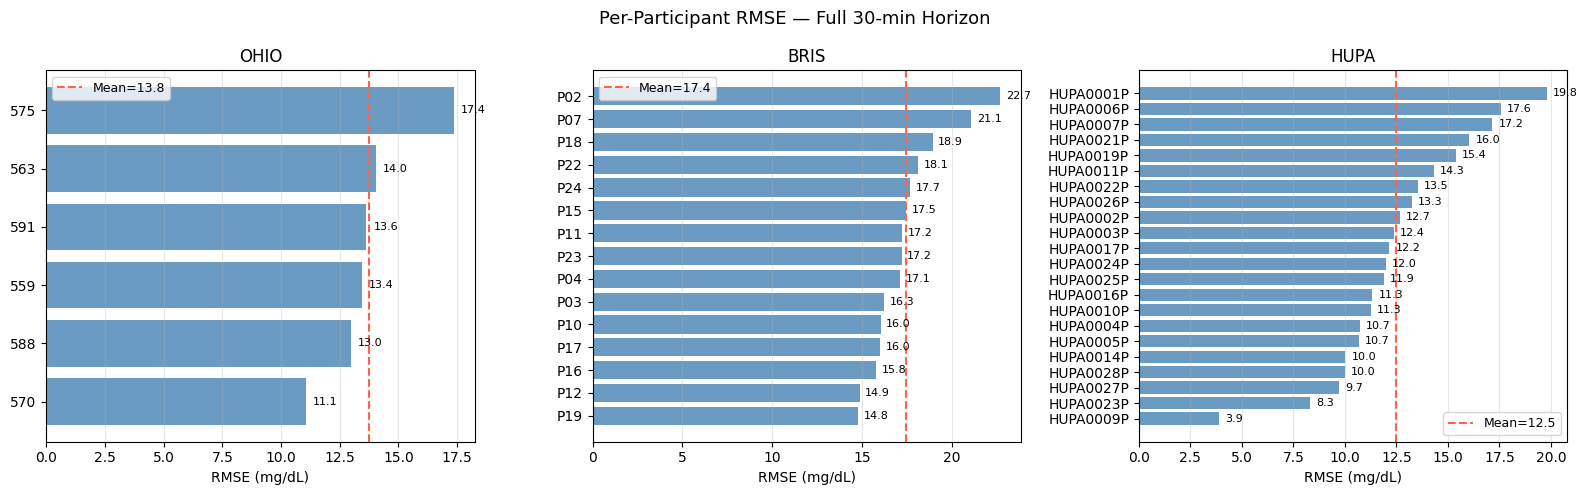

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, tag in zip(axes, DATASETS):
    df = results_df[tag].sort_values('rmse_full')
    subj_labels = [s.split('_', 1)[1] for s in df['subject']]   # strip dataset prefix
    bars = ax.barh(subj_labels, df['rmse_full'], color='steelblue', alpha=0.8)
    ax.axvline(df['rmse_full'].mean(), color='tomato', lw=1.5, ls='--',
               label=f'Mean={df.rmse_full.mean():.1f}')
    ax.set_xlabel('RMSE (mg/dL)')
    ax.set_title(tag.upper())
    ax.legend(fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, df['rmse_full']):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', fontsize=8)

plt.suptitle('Per-Participant RMSE — Full 30-min Horizon', fontsize=13)
plt.tight_layout()
# plt.savefig('../test_results/per_subject_rmse.pdf', bbox_inches='tight')
plt.show()

## 6. Scatter: Predicted vs True Glucose (all windows, t+30)

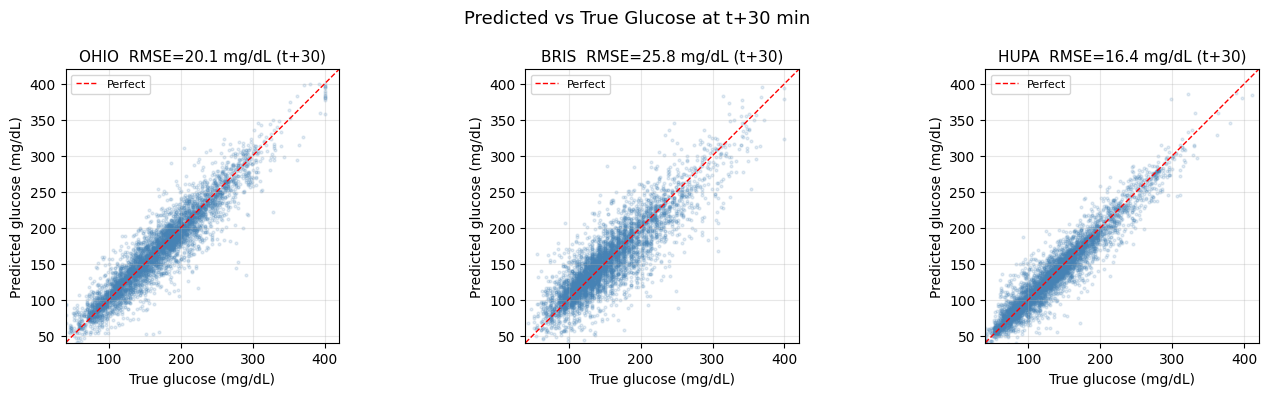

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, tag in zip(axes, DATASETS):
    d = data[tag]
    t30_pred = d['pred'][:, -1]   # t+30 prediction
    t30_true = d['true'][:, -1]   # t+30 ground truth

    # Subsample for visibility if large
    n = min(len(t30_pred), 5000)
    idx = np.random.default_rng(0).choice(len(t30_pred), n, replace=False)

    ax.scatter(t30_true[idx], t30_pred[idx], alpha=0.15, s=4, color='steelblue')
    lim = (40, 420)
    ax.plot(lim, lim, 'r--', lw=1, label='Perfect')
    rmse = np.sqrt(np.mean((t30_pred - t30_true)**2))
    ax.set_title(f'{tag.upper()}  RMSE={rmse:.1f} mg/dL (t+30)', fontsize=11)
    ax.set_xlabel('True glucose (mg/dL)')
    ax.set_ylabel('Predicted glucose (mg/dL)')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_aspect('equal')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Predicted vs True Glucose at t+30 min', fontsize=13)
plt.tight_layout()
# plt.savefig('../test_results/scatter_pred_vs_true.pdf', bbox_inches='tight')
plt.show()